# PyVBMC Example 9: Torch and JAX models and posterior exports

We fit a psychometric curve to counts of correct responses, then use the fitted
posterior in Torch and ArviZ. The model has two unknown parameters: a threshold
and a slope. Guessing and lapse rates are fixed. A short JAX section implements
the same likelihood, showing how to connect either framework to PyVBMC.

This notebook is Part 9 of the PyVBMC examples. It assumes the basic workflow
from Example 1. To run every section, use **Python 3.12 or newer** and install:

```console
python -m pip install "pyvbmc[torch,arviz]" jax notebook
```

A CPU is sufficient; see the [installation guide](https://acerbilab.github.io/pyvbmc/installation.html) for
CPU-only Torch installation. JAX is needed only for the final model section.
PyVBMC's solver uses NumPy/SciPy; framework targets exchange NumPy arrays with
it. This inexpensive model makes the workflow easy to run. PyVBMC is most
useful when target evaluations are costly or limited in number.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.special import expit

from pyvbmc import VBMC
from pyvbmc.priors import UniformBox

SEED = 9

## 1. A psychometric model and response counts

At each stimulus level $s_i$, we observe $k_i$ correct responses in $n_i$
independent trials of a two-alternative task. We model

$$
k_i \sim \operatorname{Binomial}(n_i, p(s_i)), \qquad
p(s) = \gamma + (1-\gamma-\lambda)
\operatorname{sigmoid}\bigl(\beta(s-\alpha)\bigr).
$$

Here $\alpha$ is the threshold and $\beta>0$ controls steepness. We fix the
guessing rate at $\gamma=0.5$ and the upper error rate at $\lambda=0.02$,
so the curve rises from 50% to 98% correct. This convention defines the
threshold at the midpoint of those asymptotes: $p(\alpha)=0.74$.
The derivative there is $(1-\gamma-\lambda)\beta/4$.

We simulate a small dataset. The response counts are random, but evaluating
their binomial log-likelihood is deterministic; this is an ordinary noiseless
target for PyVBMC.

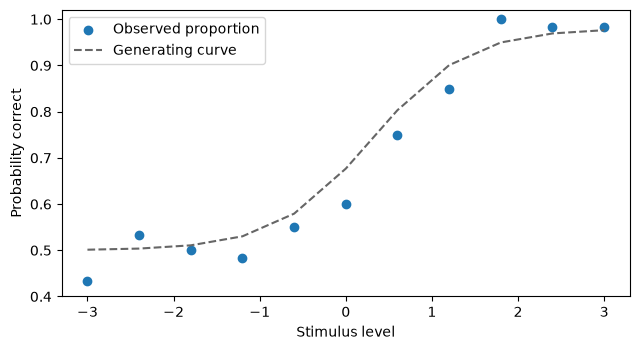

In [2]:
guess_rate = 0.5
lapse_rate = 0.02
stimulus = np.linspace(-3.0, 3.0, 11)
n_trials = np.full(stimulus.size, 60)
threshold_true, slope_true = 0.3, 1.8
probability_true = guess_rate + (1 - guess_rate - lapse_rate) * expit(
    slope_true * (stimulus - threshold_true)
)
data_rng = np.random.default_rng(SEED)
n_correct = data_rng.binomial(n_trials, probability_true)

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.scatter(stimulus, n_correct / n_trials, label="Observed proportion")
ax.plot(
    stimulus, probability_true, "--", color="0.4", label="Generating curve"
)
ax.set(xlabel="Stimulus level", ylabel="Probability correct", ylim=(0.4, 1.02))
ax.legend()
fig.tight_layout()
plt.show()

## 2. A vectorized Torch likelihood

The parameter order throughout is `[threshold, slope]`. With
`vectorized_target=True`, PyVBMC passes an `(N, 2)` NumPy array in these
original coordinates and expects an `(N,)` NumPy array of log-likelihoods.
It batches the initial-design points that need evaluation. Later calls each
have shape `(1, 2)`, because active sampling selects one point at a time.

The model below broadcasts over parameter rows and stimulus levels. We use
explicit float64 tensors on the CPU and keep the data in Torch between calls.
`Binomial.log_prob` includes the binomial normalization constants, which
matter for model evidence.

In [3]:
device = torch.device("cpu")
stimulus_t = torch.as_tensor(stimulus, dtype=torch.float64, device=device)
trials_t = torch.as_tensor(n_trials, dtype=torch.float64, device=device)
correct_t = torch.as_tensor(n_correct, dtype=torch.float64, device=device)


def response_probability_t(theta, levels):
    threshold = theta[:, 0:1]
    slope = theta[:, 1:2]
    return guess_rate + (1 - guess_rate - lapse_rate) * torch.sigmoid(
        slope * (levels[None, :] - threshold)
    )


def torch_log_likelihood(x):
    with torch.no_grad():
        theta = torch.as_tensor(x, dtype=torch.float64, device=device)
        probabilities = response_probability_t(theta, stimulus_t)
        values = (
            torch.distributions.Binomial(
                total_count=trials_t, probs=probabilities
            )
            .log_prob(correct_t)
            .sum(dim=1)
        )
    return values.detach().cpu().numpy()


check_points = np.array([[0.0, 1.0], [0.3, 1.8], [-0.5, 3.0]])
print("Batch log-likelihoods:", torch_log_likelihood(check_points))
print("Single-row output shape:", torch_log_likelihood(check_points[:1]).shape)

Batch log-likelihoods: [-36.16985449 -26.17829108 -69.80600386]
Single-row output shape: (1,)


The return conversion completes any device work and delivers host NumPy
values to PyVBMC. A vectorized target returns an array even for one point.
PyVBMC needs likelihood values only, so target evaluation disables gradient
recording; the Torch model function remains usable for other computations.

## 3. Fit threshold and slope

We choose independent uniform priors for threshold in `[-3, 3]` and slope in
`[0.2, 6]`. These finite hard bounds express the prior support. The narrower
plausible box describes where we expect most posterior mass and helps
initialize the search; it does not truncate the prior.

`prior=` supplies the normalized prior separately. The target returns only
the log-likelihood, and PyVBMC adds the log-prior once. A separate prior
keeps its ordinary single-point interface even with a batched likelihood.

In [4]:
lower_bounds = np.array([-3.0, 0.2])
upper_bounds = np.array([3.0, 6.0])
plausible_lower = np.array([-1.0, 0.5])
plausible_upper = np.array([1.0, 3.0])
x0 = np.array([0.0, 1.0])
prior = UniformBox(lower_bounds, upper_bounds)
options = {"vectorized_target": True, "display": "off"}

vbmc = VBMC(
    torch_log_likelihood,
    x0,
    lower_bounds,
    upper_bounds,
    plausible_lower,
    plausible_upper,
    prior=prior,
    options=options,
    seed=SEED,
)
vp, results = vbmc.optimize()
print("Convergence status:", results["convergence_status"])
print("Target evaluations:", results["func_count"])
print(f"ELBO: {results['elbo']:.3f} +/- {results['elbo_sd']:.3f}")

Reshaping x0 to row vector.


Reshaping lower bounds to (1, 2).


Reshaping upper bounds to (1, 2).


Reshaping plausible lower bounds to (1, 2).


Reshaping plausible upper bounds to (1, 2).


Inference terminated: variational solution stable for options.tol_stable_count fcn evaluations.


Estimated ELBO: -28.004 +/-0.001.


Convergence status: probable
Target evaluations: 70
ELBO: -28.004 +/- 0.001


Read the convergence status before using the result. `elbo_sd` describes
uncertainty in the ELBO estimate; it is not the error relative to the true
log evidence. One converged run is a starting point for validation: use
different seeds and starting points to check agreement, as in Example 4.
The explicit seed controls PyVBMC's random stream; `data_rng` above controls
the simulated dataset independently.

## 4. Torch posterior samples and predicted response probabilities

`vp.to_torch()` makes an independent distribution snapshot. Its defaults are
CPU, float64 and **original parameter coordinates**, so each draw contains
`[threshold, slope]` within the hard bounds. PyVBMC's internal transformations
are already accounted for. Conversion draws no random numbers; sampling the
export uses Torch's random generator, seeded separately below.

Posterior sample shape: (2000, 2)


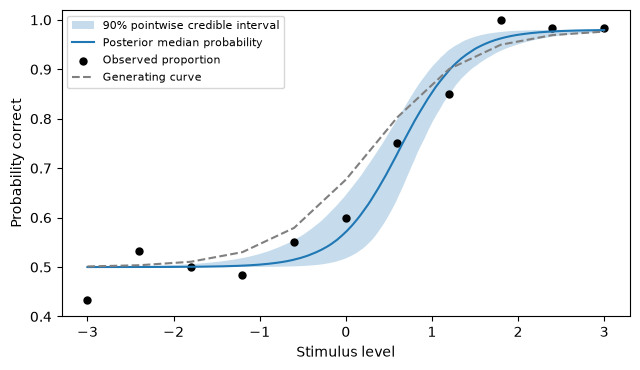

In [5]:
posterior_t = vp.to_torch()
torch.manual_seed(SEED)
parameter_draws_t = posterior_t.sample((2000,))
print("Posterior sample shape:", tuple(parameter_draws_t.shape))

# The exported density agrees with the NumPy posterior at the same points.
np.testing.assert_allclose(
    posterior_t.log_prob(parameter_draws_t[:10]).detach().numpy(),
    vp.pdf(parameter_draws_t[:10].numpy(), log_flag=True).ravel(),
    rtol=1e-10,
    atol=1e-10,
)

grid_t = torch.linspace(-3.0, 3.0, 200, dtype=torch.float64)
probability_draws_t = response_probability_t(parameter_draws_t, grid_t)
bands = torch.quantile(
    probability_draws_t,
    torch.tensor([0.05, 0.5, 0.95], dtype=torch.float64),
    dim=0,
).numpy()

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.fill_between(
    grid_t.numpy(),
    bands[0],
    bands[2],
    alpha=0.25,
    label="90% pointwise credible interval",
)
ax.plot(grid_t.numpy(), bands[1], label="Posterior median probability")
ax.scatter(
    stimulus,
    n_correct / n_trials,
    color="black",
    s=25,
    label="Observed proportion",
)
ax.plot(
    stimulus, probability_true, "--", color="0.5", label="Generating curve"
)
ax.set(xlabel="Stimulus level", ylabel="Probability correct", ylim=(0.4, 1.02))
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

The band describes posterior uncertainty in the response probability at each
stimulus level. Future observed proportions also vary because of binomial
sampling: drawing future counts would require an additional binomial draw
for each parameter sample. Observed proportions can therefore fall outside
this probability band. Finite response counts can also move the fitted curve
away from the generating curve. These are pointwise intervals, not a simultaneous
band for the entire curve.

The exported `log_prob` is also differentiable with respect to its input.
Here is the gradient of the approximate log posterior in the original
threshold and slope coordinates. It does not differentiate through the
PyVBMC fitting procedure. For bounded parameters, density inputs must be
strictly inside the hard bounds.

In [6]:
point_t = parameter_draws_t[0].detach().clone().requires_grad_(True)
log_density_t = posterior_t.log_prob(point_t)
gradient_t = torch.autograd.grad(log_density_t, point_t)[0]
print("Point [threshold, slope]:", point_t.detach().numpy())
print("Log-density gradient:", gradient_t.detach().numpy())

Point [threshold, slope]:

 [0.81803583 2.41036705]
Log-density gradient: [-14.17884344   2.10006394]


## 5. Named posterior summaries in ArviZ

`vp.to_arviz()` draws new independent samples using `vp.rng` and returns a
DataTree with one posterior chain. `var_names` follows the same parameter
order as the target. This export advances PyVBMC's posterior random stream,
independently of the Torch samples above.

We request marginal statistics with `kind="stats"`. MCMC convergence
diagnostics on independent variational draws do not assess how well the
approximation matches the true posterior.

In [7]:
import arviz as az

posterior_data = vp.to_arviz(n_samples=2000, var_names=["threshold", "slope"])
print(az.summary(posterior_data, kind="stats", round_to=3))

            mean     sd  eti89_lb  eti89_ub
threshold  0.618  0.145     0.375     0.850
slope      2.887  0.710     1.912     4.181


## 6. The same input model in JAX

For a JAX model, enable [64-bit computation](https://docs.jax.dev/en/latest/default_dtypes.html)
before creating model arrays. The compiled function below computes the same
normalized binomial likelihood. Its wrapper returns host NumPy values using
`jax.device_get`, which waits for the result before returning it to PyVBMC.
The first call for each input shape includes compilation work.

In [8]:
import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
from jax.scipy.stats import binom

stimulus_j = jnp.asarray(stimulus, dtype=jnp.float64)
trials_j = jnp.asarray(n_trials, dtype=jnp.float64)
correct_j = jnp.asarray(n_correct, dtype=jnp.float64)


@jax.jit
def jax_log_likelihood_values(theta):
    threshold = theta[:, 0:1]
    slope = theta[:, 1:2]
    probabilities = guess_rate + (
        1 - guess_rate - lapse_rate
    ) * jax.nn.sigmoid(slope * (stimulus_j[None, :] - threshold))
    return binom.logpmf(correct_j, trials_j, probabilities).sum(axis=1)


def jax_log_likelihood(x):
    values = jax_log_likelihood_values(jnp.asarray(x, dtype=jnp.float64))
    return np.asarray(jax.device_get(values), dtype=np.float64)


for points in (check_points, check_points[:1]):
    np.testing.assert_allclose(
        jax_log_likelihood(points),
        torch_log_likelihood(points),
        rtol=1e-10,
        atol=1e-10,
    )
print("Torch and JAX likelihoods agree for batch and single-row inputs.")

Torch and JAX likelihoods agree for batch and single-row inputs.


To fit with this target, replace `torch_log_likelihood` by
`jax_log_likelihood` in the `VBMC` constructor in Section 3 and call
`optimize()`. The bounds, prior and `vectorized_target` option stay the same.
The returned `VariationalPosterior` supports the same Torch and ArviZ exports
regardless of which framework evaluated the likelihood.

## 7. What to reuse in your own model

- Wrap the model with explicit precision, NumPy inputs and host NumPy outputs.
  Opt into batching only when the target accepts `(N, D)` inputs, including
  `(1, D)` after initialization.
- Supply a normalized prior and retain likelihood constants when estimating
  model evidence. Choose hard bounds for support and plausible bounds to
  guide initialization.
- Use Torch posterior samples for model predictions and `log_prob` for
  differentiable density evaluation. Use named ArviZ draws for summaries.
- Check the inference result and agreement across independent runs; increasing
  the number of exported samples only reduces sampling error within the fitted
  approximation.

See Example 7 for combining fitted runs with S-VBMC, and Example 8 for a
PyMC model with structured posterior export and posterior predictive sampling.